In [1]:
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, Aer, execute
from qiskit.visualization import plot_histogram
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.circuit.library import CCXGate, MCMT
from qiskit.circuit.library.standard_gates import ZGate, XGate
from qiskit.circuit import AncillaRegister
import numpy as np

/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78946/1167011239.py:38: DeprecationWarning: The 'qiskit.Aer' entry point is deprecated and will be removed in Qiskit 1.0. You should use 'qiskit_aer.Aer' directly instead.
  simulator = Aer.get_backend('qasm_simulator')
/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78946/1167011239.py:40: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=1000)


                    ┌───┐┌───┐         ┌─┐
q_0: ───────────────┤ X ├┤ Z ├─────────┤M├
          ┌───┐┌───┐└─┬─┘└───┘┌─┐      └╥┘
q_1: ─────┤ X ├┤ Z ├──┼───────┤M├───────╫─
     ┌───┐└─┬─┘├───┤  │   ┌─┐ └╥┘       ║ 
q_2: ┤ X ├──┼──┤ Z ├──┼───┤M├──╫────────╫─
     └─┬─┘  │  └┬─┬┘  │   └╥┘  ║        ║ 
q_3: ──o────o───┤M├───┼────╫───╫────────╫─
       │    │   └╥┘   │    ║   ║ ┌─┐    ║ 
q_4: ──o────┼────╫────o────╫───╫─┤M├────╫─
            │    ║    │    ║   ║ └╥┘┌─┐ ║ 
q_5: ───────o────╫────o────╫───╫──╫─┤M├─╫─
                 ║         ║   ║  ║ └╥┘ ║ 
c: 6/════════════╩═════════╩═══╩══╩══╩══╩═
                 3         2   1  4  5  0 


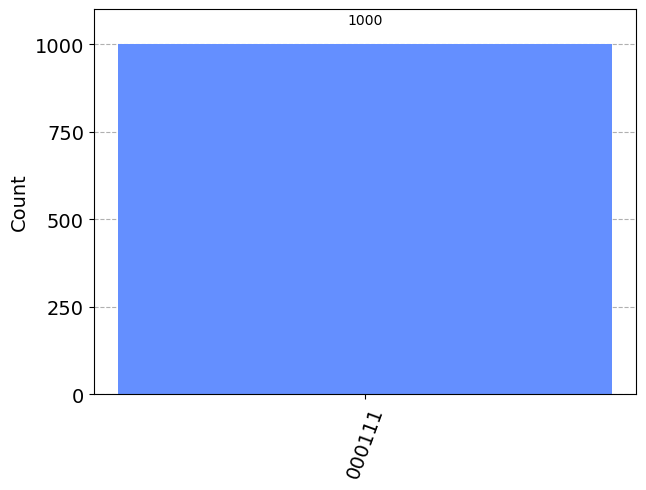

In [2]:
# # qc.x(0)
# # qc.x(1)
# # qc.x(2)

# # for i in range(4):
# #     qc.h(i)

# # Apply CNOT gates to entangle the target qubit with the ancilla based on the control qubits
# qc.ccx(0, 1, 4)
# qc.ccx(2, 4, 3)

# # To complete the Toffoli logic, reverse the operations on the ancilla qubit
# qc.ccx(0, 1, 4)

# # Apply Hadamard again to the target to exit superposition, completing the 4-qubit Toffoli operation
# # qc.h(3)

# # Add more gates as needed and/or measure qubits

qr = QuantumRegister(6, 'q')
cr = ClassicalRegister(6, 'c')
qc = QuantumCircuit(qr, cr)

# qc.h(0)
# qc.h(1)
# qc.h(2)

ccx_00 = CCXGate(ctrl_state='00')
qc.append(ccx_00, [3, 4, 2])
qc.append(ccx_00, [3, 5, 1])
qc.append(ccx_00, [4, 5, 0])
qc.z(0)
qc.z(1)
qc.z(2)

qc.measure(qr, cr)

simulator = Aer.get_backend('qasm_simulator')

job = execute(qc, simulator, shots=1000)

result = job.result()

counts = result.get_counts(qc)

# # Draw the circuit
print(qc.draw())
plot_histogram(counts)

       ┌───┐                           ┌───┐     ┌─┐         
  q_0: ┤ H ├──■────────■────────────■──┤ H ├─────┤M├─────────
       ├───┤  │        │            │  ├───┤     └╥┘┌─┐      
  q_1: ┤ H ├──■────────┼─────■──────■──┤ H ├──────╫─┤M├──────
       ├───┤  │        │     │      │  └───┘┌───┐ ║ └╥┘┌─┐   
  q_2: ┤ H ├──┼────■───┼──■──┼──────┼────■──┤ H ├─╫──╫─┤M├───
       ├───┤  │    │   │  │  │      │    │  ├───┤ ║  ║ └╥┘┌─┐
  q_3: ┤ H ├──┼────■───┼──┼──┼──■───┼────■──┤ H ├─╫──╫──╫─┤M├
       ├───┤┌─┴─┐  │   │  │  │  │ ┌─┴─┐  │  ├───┤ ║  ║  ║ └╥┘
anc_0: ┤ X ├┤ X ├──┼───■──┼──■──┼─┤ X ├──┼──┤ X ├─╫──╫──╫──╫─
       ├───┤└───┘┌─┴─┐    │     │ └───┘┌─┴─┐├───┤ ║  ║  ║  ║ 
anc_1: ┤ X ├─────┤ X ├────■─────■──────┤ X ├┤ X ├─╫──╫──╫──╫─
       └───┘     └───┘                 └───┘└───┘ ║  ║  ║  ║ 
  c: 4/═══════════════════════════════════════════╩══╩══╩══╩═
                                                  0  1  2  3 


/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78946/23788689.py:47: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=1000)


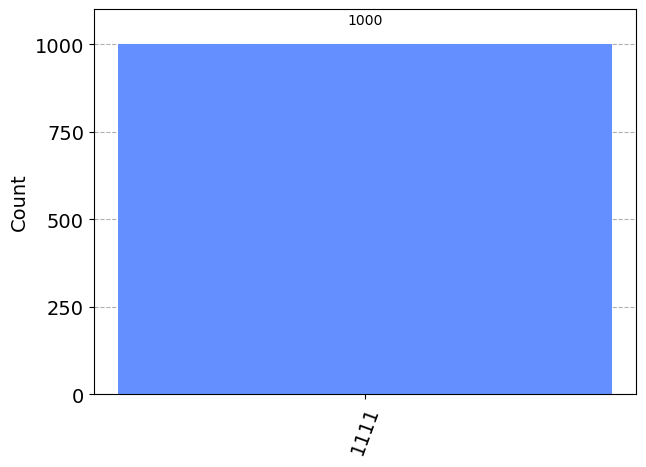

In [3]:
# Create a Quantum Circuit with 4 qubits + 2 ancilla qubits
qr = QuantumRegister(4, 'q')
anc = AncillaRegister(2, 'anc')
cr = ClassicalRegister(4, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize ancilla qubits to |1> state to use them as control for the CCX operation
qc.x(anc)

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

# Use ancilla qubits to control the application of X gates on them based on the state of the 4 qubits
qc.ccx(qr[0], qr[1], anc[0])
qc.ccx(qr[2], qr[3], anc[1])

# Apply a CCX gate with ancilla qubits as controls and apply a Z gate to flip the phase
# Note: A direct Z control is not standard, but you can implement a CZ with an X before and after on the target for a similar effect if needed.
# Since you're looking for a negative phase flip when NOT in |0000>, we use ancilla to control this.

# The approach is to use the ancilla qubits to effectively mark the non-|0000> state
# and then apply Z to each original qubit conditionally. But we have to ensure not to disturb the main computation,
# so we carefully reset the ancilla qubits back to their original state as needed.

# Apply Z gates conditionally (similar to the original 3-qubit circuit logic)
qc.cz(anc[0], qr[0])
qc.cz(anc[0], qr[1])
qc.cz(anc[1], qr[2])
qc.cz(anc[1], qr[3])

# Reset ancilla qubits back to their original state to ensure they don't interfere with further computation
qc.ccx(qr[0], qr[1], anc[0])
qc.ccx(qr[2], qr[3], anc[1])
qc.x(anc)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)

# Include measurements if desired
qc.measure(qr, cr)

simulator = Aer.get_backend('qasm_simulator')

job = execute(qc, simulator, shots=1000)

result = job.result()

counts = result.get_counts(qc)

# # Draw the circuit
print(qc.draw())
plot_histogram(counts)

       ┌───┐     ┌───┐┌─┐            
  q_0: ┤ H ├──■──┤ H ├┤M├────────────
       ├───┤  │  ├───┤└╥┘┌─┐         
  q_1: ┤ H ├──■──┤ H ├─╫─┤M├─────────
       ├───┤  │  ├───┤ ║ └╥┘┌─┐      
  q_2: ┤ H ├──■──┤ H ├─╫──╫─┤M├──────
       ├───┤  │  ├───┤ ║  ║ └╥┘┌─┐   
  q_3: ┤ H ├──■──┤ H ├─╫──╫──╫─┤M├───
       ├───┤  │  ├───┤ ║  ║  ║ └╥┘┌─┐
  q_4: ┤ H ├──■──┤ H ├─╫──╫──╫──╫─┤M├
       └───┘  │  └───┘ ║  ║  ║  ║ └╥┘
anc_0: ───────┼────────╫──╫──╫──╫──╫─
       ┌───┐┌─┴─┐┌───┐ ║  ║  ║  ║  ║ 
anc_1: ┤ H ├┤ X ├┤ H ├─╫──╫──╫──╫──╫─
       └───┘└───┘└───┘ ║  ║  ║  ║  ║ 
  c: 5/════════════════╩══╩══╩══╩══╩═
                       0  1  2  3  4 


/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78946/1890733563.py:76: DeprecationWarning: The method ``qiskit.circuit.quantumcircuit.QuantumCircuit.mct()`` is deprecated as of qiskit 0.45.0. It will be removed in the Qiskit 1.0.0 release. Use QuantumCircuit.mcx as direct replacement.
  qc.mct([qr[0], qr[1], qr[2], qr[3], qr[4]], anc[1], anc[:1], mode='noancilla')  # Multi-controlled Toffoli
/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78946/1890733563.py:88: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=10000)


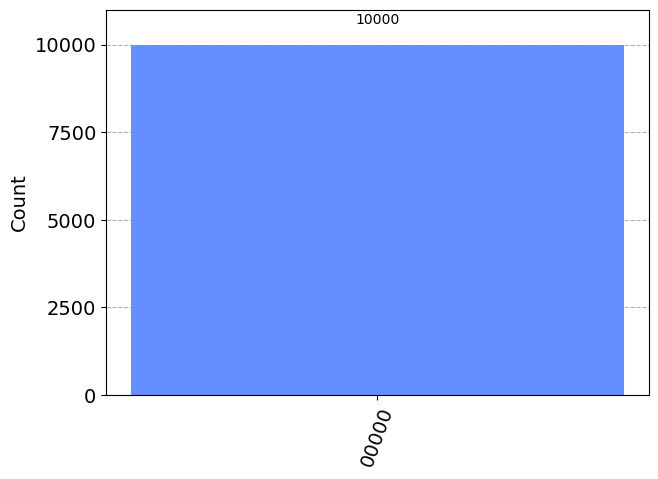

In [8]:
# # Create a Quantum Circuit with 5 qubits + 2 ancilla qubits for the control logic
# qr = QuantumRegister(5, 'q')
# anc = QuantumRegister(2, 'anc')  # Using 2 ancilla qubits for intermediate control checks
# cr = ClassicalRegister(5, 'c')
# qc = QuantumCircuit(qr, anc, cr)

# # Prepare the ancilla qubits in the |1> state to facilitate the control checks
# qc.x(anc)
# qc.h(0)
# qc.h(1)
# qc.h(2)
# qc.h(3)
# qc.h(4)

# # Determine if any of the 5 qubits are in the |1> state using the ancilla qubits
# # This requires a series of CCX (Toffoli) gates to propagate the "any qubit in |1>" condition to the ancilla qubits
# qc.ccx(qr[0], qr[1], anc[0])
# qc.ccx(qr[2], anc[0], anc[1])
# qc.ccx(qr[3], qr[4], anc[0])

# # Using the ancilla qubits' state to conditionally apply Z gates to flip the phase
# # Since we're targeting a negative phase flip when NOT all qubits are in |00000>, the conditions are set accordingly
# qc.cz(anc[1], qr[0])
# qc.cz(anc[1], qr[1])
# qc.cz(anc[1], qr[2])
# qc.cz(anc[1], qr[3])
# qc.cz(anc[1], qr[4])

# # Reset the ancilla qubits back to their original state (|0>) to ensure they can be reused or don't affect subsequent operations
# qc.ccx(qr[3], qr[4], anc[0])
# qc.ccx(qr[2], anc[0], anc[1])
# qc.ccx(qr[0], qr[1], anc[0])
# qc.x(anc)
# qc.h(0)
# qc.h(1)
# qc.h(2)
# qc.h(3)
# qc.h(4)

# # Measurement of the 5 qubits (excluding ancilla qubits from measurement)
# qc.measure(qr, cr)

# simulator = Aer.get_backend('qasm_simulator')

# job = execute(qc, simulator, shots=10000)

# result = job.result()

# counts = result.get_counts(qc)

# # # Draw the circuit
# print(qc.draw())
# plot_histogram(counts)




# Create a Quantum Circuit with 5 qubits + 2 ancilla qubits for the control logic
qr = QuantumRegister(5, 'q')
anc = QuantumRegister(2, 'anc')  # Using 2 ancilla qubits for intermediate control checks
cr = ClassicalRegister(5, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Initialize the qubits in superposition to check the phase flip on all states except |00000>
for q in qr:
    qc.h(q)

# Since we want a phase flip for states other than |00000>, we do not need to prepare ancilla qubits in |1>
# Instead, we use them directly for the intended control operations

# To ensure that we apply a phase flip only when any qubit is |1>, we can directly apply a multi-controlled Z gate
# However, Qiskit doesn't support a 5-controlled Z gate directly, so we use ancilla qubits for decomposition

# Multi-controlled Z gate using ancilla qubits
qc.h(anc[1])  # Prepare the last ancilla qubit as control for the Z gate
qc.mct([qr[0], qr[1], qr[2], qr[3], qr[4]], anc[1], anc[:1], mode='noancilla')  # Multi-controlled Toffoli
qc.h(anc[1])  # Uncompute: This creates the phase flip on the target when controls are NOT all |00000>

# Since we apply H again to all qubits, the phase flip is translated to measurable amplitude changes
for q in qr:
    qc.h(q)

# Measurement of the 5 qubits
qc.measure(qr, cr)

# Execute the circuit
simulator = Aer.get_backend('qasm_simulator')
job = execute(qc, simulator, shots=10000)
result = job.result()
counts = result.get_counts(qc)

# Draw the circuit and plot the histogram
print(qc.draw())
plot_histogram(counts)


In [2]:
# Setup
qr = QuantumRegister(5, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(5, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Step 1: Apply Hadamard gates to all qubits to create superposition
for q in qr:
    qc.h(q)

# Prepare the ancilla qubit in the |-> state for phase kickback. (phase kickback = )
qc.x(anc[0])
qc.h(anc[0])
#qc.initialize([1, -1]/np.sqrt(2), anc[0])

# Invert qubits to condition on |00000>
qc.x(qr)

# Apply a multi-controlled Toffoli gate
qc.mct(qr, anc[0], None, mode='noancilla')

# Uncompute: Reset the qubits to their superposition states
qc.x(qr)

/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_93334/331984730.py:20: DeprecationWarning: The method ``qiskit.circuit.quantumcircuit.QuantumCircuit.mct()`` is deprecated as of qiskit 0.45.0. It will be removed in the Qiskit 1.0.0 release. Use QuantumCircuit.mcx as direct replacement.
  qc.mct(qr, anc[0], None, mode='noancilla')


/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_93334/3348844610.py:28: DeprecationWarning: The 'qiskit.Aer' entry point is deprecated and will be removed in Qiskit 1.0. You should use 'qiskit_aer.Aer' directly instead.
  simulator = Aer.get_backend('qasm_simulator')
/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_93334/3348844610.py:29: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=1024)


     ┌───┐┌───┐     ┌───┐┌───┐┌───┐┌───────┐┌───┐┌───┐┌─┐            
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤0      ├┤ X ├┤ H ├┤M├────────────
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤└╥┘┌─┐         
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤1      ├┤ X ├┤ H ├─╫─┤M├─────────
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤ ║ └╥┘┌─┐      
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤2      ├┤ X ├┤ H ├─╫──╫─┤M├──────
     ├───┤├───┤  │  ├───┤├───┤├───┤│  mcmt │├───┤├───┤ ║  ║ └╥┘┌─┐   
q_3: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤3      ├┤ X ├┤ H ├─╫──╫──╫─┤M├───
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤ ║  ║  ║ └╥┘┌─┐
q_4: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤4      ├┤ X ├┤ H ├─╫──╫──╫──╫─┤M├
     ├───┤├───┤┌─┴─┐└───┘└───┘└───┘│       │└───┘└───┘ ║  ║  ║  ║ └╥┘
anc: ┤ X ├┤ H ├┤ X ├───────────────┤5      ├───────────╫──╫──╫──╫──╫─
     └───┘└───┘└───┘               └───────┘           ║  ║  ║  ║  ║ 
c: 5/══════════════════════════════════════════════════╩══╩══╩══╩══╩═
                    

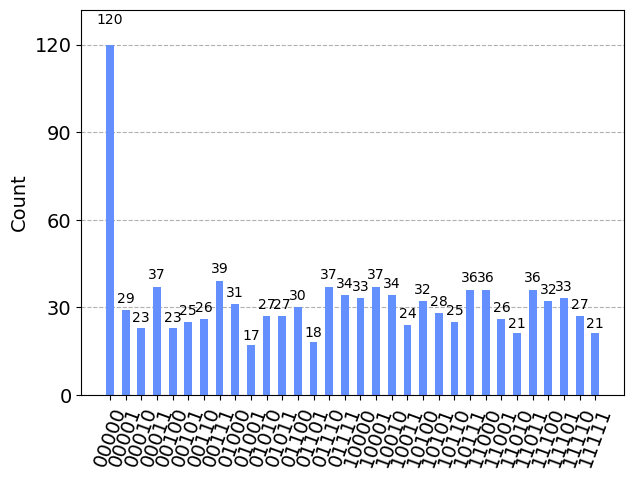

In [3]:
# Grover Diffusion Operator
# 1. Apply Hadamard gates to all qubits
for q in qr:
    qc.h(q)

# 2. Apply X gates to all qubits to invert the states
for q in qr:
    qc.x(q)

# 3. Apply multi-controlled Z gate (MCZ) using an ancilla if necessary
# Since Qiskit does not have a direct MCZ gate for 5 qubits, we implement it using MCMT (Multi-Control Multi-Target)
# Note: This requires the circuit to have ancillary qubits for decomposition if not using 'noancilla' mode
# Here, using MCMT as an example to apply a single Z controlled by all qubits. This gate applies a phase flip of π (i.e., multiplies the state by -1) only if all qubits are in the ∣1⟩ state.
qc.append(MCMT('z', 5, 1), qr[:] + [anc[0]])

# 4. Apply X gates again to revert the inversion
for q in qr:
    qc.x(q)

# 5. Apply Hadamard gates to all qubits to complete the diffusion operator
for q in qr:
    qc.h(q)

# Measure the qubits
qc.measure(qr, cr)

# Execute the circuit
simulator = Aer.get_backend('qasm_simulator')
job = execute(qc, simulator, shots=1024)
result = job.result()
counts = result.get_counts(qc)

# Visualize the results
print(qc.draw(output='text'))
plot_histogram(counts)

# See if I can loop over multiple diffusion operator to maximise the count even more.

In [10]:
# Execute the circuit using the statevector simulator
simulator = Aer.get_backend('statevector_simulator')
result = execute(qc, simulator).result()
statevector = result.get_statevector(qc)

print("Statevector:", statevector)

Statevector: Statevector([ 0.63187921-0.26173294j, -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ,
             -0.        +0.j        , -0. 

/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_91584/1202946900.py:3: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, simulator).result()


/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78615/3508312398.py:29: DeprecationWarning: The method ``qiskit.circuit.quantumcircuit.QuantumCircuit.mct()`` is deprecated as of qiskit 0.45.0. It will be removed in the Qiskit 1.0.0 release. Use QuantumCircuit.mcx as direct replacement.
  qc.mct(qr, anc[0], None, mode='noancilla')
/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78615/3508312398.py:59: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=100000)


     ┌───┐┌───┐     ┌───┐┌───┐┌───┐┌───────┐┌───┐┌───┐┌───┐┌───┐     ┌───┐┌───┐»
q_0: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤0      ├┤ X ├┤ H ├┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤├───┤├───┤  │  ├───┤├───┤»
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤1      ├┤ X ├┤ H ├┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤├───┤├───┤  │  ├───┤├───┤»
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤2 mcmt ├┤ X ├┤ H ├┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤├───┤├───┤  │  ├───┤├───┤»
q_3: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤3      ├┤ X ├┤ H ├┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤├───┤  │  ├───┤├───┤├───┤│       │├───┤├───┤├───┤├───┤  │  ├───┤├───┤»
q_4: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├┤4      ├┤ X ├┤ H ├┤ H ├┤ X ├──■──┤ X ├┤ H ├»
     ├───┤├───┤┌─┴─┐├───┤├───┤└───┘└───────┘└───┘└───┘└───┘└───┘┌─┴─┐├───┤├───┤»
anc: ┤ X ├┤ H ├┤ X ├┤ X ├┤ H ├──────────────────────────────────┤ X ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└──

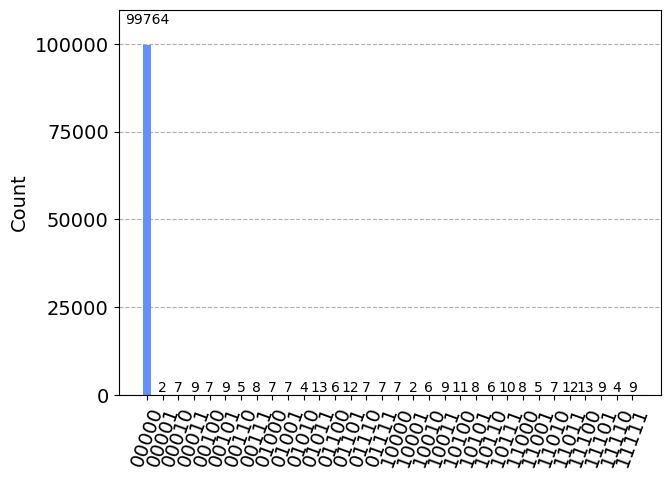

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, Aer, execute
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import MCMT
import numpy as np

# Setup
qr = QuantumRegister(5, 'q')
anc = QuantumRegister(1, 'anc')
cr = ClassicalRegister(5, 'c')
qc = QuantumCircuit(qr, anc, cr)

# Number of Grover iterations
num_iterations = 4  # Adjust based on experiments or theoretical calculation

for _ in range(num_iterations):
    
    # Apply Hadamard gates to all qubits to create superposition
    for q in qr:
        qc.h(q)

    # Prepare the ancilla qubit in the |-> state for phase kickback
    qc.x(anc[0])
    qc.h(anc[0])

    # Invert qubits to condition on |00000>
    qc.x(qr)

    # Apply a multi-controlled Toffoli gate
    qc.mct(qr, anc[0], None, mode='noancilla')

    # Uncompute: Reset the qubits to their superposition states
    qc.x(qr)

    # Grover Diffusion Operator
    # 1. Apply Hadamard gates to all qubits
    for q in qr:
        qc.h(q)

    # 2. Apply X gates to all qubits to invert the states
    for q in qr:
        qc.x(q)

    # 3. Apply multi-controlled Z gate (MCZ) to the five qubits
    qc.append(MCMT('z', 4, 1), qr[:])

    # 4. Apply X gates again to revert the inversion
    for q in qr:
        qc.x(q)

    # 5. Apply Hadamard gates to all qubits to complete the diffusion operator
    for q in qr:
        qc.h(q)

# Measure the qubits
qc.measure(qr, cr)

# Execute the circuit
simulator = Aer.get_backend('qasm_simulator')
job = execute(qc, simulator, shots=100000)
result = job.result()
counts = result.get_counts(qc)

# Visualize the results
print(qc.draw(output='text'))
plot_histogram(counts)

/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78615/3322758662.py:32: DeprecationWarning: The method ``qiskit.circuit.quantumcircuit.QuantumCircuit.mct()`` is deprecated as of qiskit 0.45.0. It will be removed in the Qiskit 1.0.0 release. Use QuantumCircuit.mcx as direct replacement.
  qc.mct(qr, anc[0], None, mode='noancilla')
/var/folders/mp/klk2l9k97nv804srb8zwdq6c0000gn/T/ipykernel_78615/3322758662.py:62: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  job = execute(qc, simulator, shots=100000)


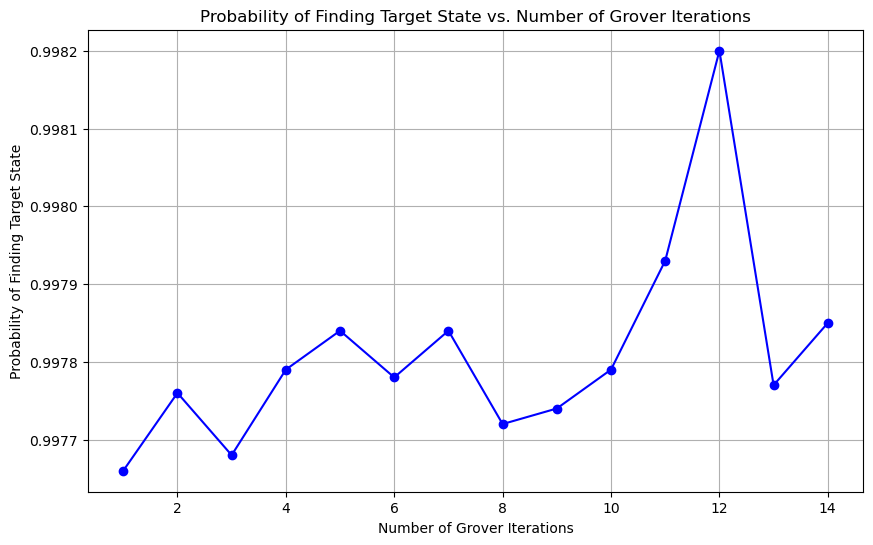

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, Aer, execute
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import MCMT
import numpy as np
import matplotlib.pyplot as plt

# Function to perform Grover's algorithm with a specified number of iterations
def grover_experiment(num_qubits, num_iterations):
    # Setup
    qr = QuantumRegister(5, 'q')
    anc = QuantumRegister(1, 'anc')
    cr = ClassicalRegister(5, 'c')
    qc = QuantumCircuit(qr, anc, cr)

    # Number of Grover iterations
    num_iterations = 4  # Adjust based on experiments or theoretical calculation

    for _ in range(num_iterations):

        # Step 1: Apply Hadamard gates to all qubits to create superposition
        for q in qr:
            qc.h(q)

        # Prepare the ancilla qubit in the |-> state for phase kickback
        qc.x(anc[0])
        qc.h(anc[0])

        # Invert qubits to condition on |00000>
        qc.x(qr)

        # Apply a multi-controlled Toffoli gate
        qc.mct(qr, anc[0], None, mode='noancilla')

        # Uncompute: Reset the qubits to their superposition states
        qc.x(qr)

        # Grover Diffusion Operator
        # 1. Apply Hadamard gates to all qubits
        for q in qr:
            qc.h(q)

        # 2. Apply X gates to all qubits to invert the states
        for q in qr:
            qc.x(q)

        # 3. Apply multi-controlled Z gate (MCZ) using an ancilla if necessary
        qc.append(MCMT('z', 4, 1), qr[:])

        # 4. Apply X gates again to revert the inversion
        for q in qr:
            qc.x(q)

        # 5. Apply Hadamard gates to all qubits to complete the diffusion operator
        for q in qr:
            qc.h(q)

    # Measure the qubits
    qc.measure(qr, cr)

    # Execute the circuit
    simulator = Aer.get_backend('qasm_simulator')
    job = execute(qc, simulator, shots=100000)
    result = job.result()
    counts = result.get_counts(qc)
    
    # Calculate and return the probability of finding the |00000> state
    target_state = '0' * num_qubits
    probability = counts.get(target_state, 0) / 100000
    return probability

# Range of Grover iterations to test
iterations_range = range(1, 15)
probabilities = [grover_experiment(5, i) for i in iterations_range]

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(iterations_range, probabilities, marker='o', linestyle='-', color='b')
plt.title('Probability of Finding Target State vs. Number of Grover Iterations')
plt.xlabel('Number of Grover Iterations')
plt.ylabel('Probability of Finding Target State')
plt.grid(True)
plt.show()
